<a href="https://colab.research.google.com/github/SEU_USUARIO/dog-breed-classifier/blob/main/DogBreedClassifier_FIAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificador de Racas de Caes com Visao Computacional

**Disciplina:** Disruptive Architectures: IoT, IOB & Generative IA  
**Instituicao:** FIAP  
**Sprint:** 1 Sprint - Entrega  

---

## Descricao do Projeto

Este notebook implementa um **classificador de racas de caes** utilizando um modelo **YOLOv8** treinado com imagens anotadas e organizadas no dataset incluso neste repositorio.

O fluxo completo do projeto:

1. Clona o repositorio do GitHub com o dataset ja organizado (`train / valid / test`)
2. Treina o modelo YOLOv8 com as imagens do dataset
3. Captura imagem via **webcam** (camera do navegador no Google Colab)
4. Classifica a raca usando o modelo treinado (`best.pt`)
5. Exibe o **output visual com OpenCV** — resultado sobreposto na imagem
6. Registra a deteccao em log simulando um sistema IoT

---

## Racas Identificadas pelo Modelo

| # | Classe | Raca |
|---|--------|------|
| 1 | `Beagle` | Beagle |
| 2 | `Boxer` | Boxer |
| 3 | `Bulldog` | Bulldog |
| 4 | `Dachshund` | Dachshund (Salsicha) |
| 5 | `German_Shepherd` | Pastor Alemao |
| 6 | `Golden_Retriever` | Golden Retriever |
| 7 | `Labrador_Retriever` | Labrador Retriever |
| 8 | `Poodle` | Poodle |
| 9 | `Rottweiler` | Rottweiler |
| 10 | `Yorkshire_Terrier` | Yorkshire Terrier |

---

## Tecnologias Utilizadas

| Tecnologia | Funcao |
|------------|--------|
| **YOLOv8** (Ultralytics) | Modelo de classificacao de imagens |
| **OpenCV** | Processamento de imagem e output visual |
| **Google Colab + GPU T4** | Ambiente de execucao |
| **GitHub** | Repositorio do dataset e codigo-fonte |

---

**Observacoes importantes**  
- Habilite a **GPU T4** antes de executar: `Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU`  
- Execute as celulas **em ordem**  
- Na celula da camera, clique em **Capturar Foto** quando o video aparecer


---
## Secao 1 - Instalacao das Dependencias

Instalamos a biblioteca **Ultralytics**, que fornece o YOLOv8 pronto para uso.

Documentacao oficial: https://docs.ultralytics.com/


In [1]:
# Instalando a biblioteca Ultralytics (YOLOv8)
!pip install ultralytics -q

print('Dependencias instaladas com sucesso!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.8 MB/s eta 0:00:00
Dependencias instaladas com sucesso!


---
## Secao 2 - Importacao das Bibliotecas

Importamos todas as bibliotecas utilizadas no projeto:

- `YOLO` - classe principal do modelo YOLOv8  
- `cv2` - OpenCV para manipulacao e output visual das imagens  
- `Javascript` / `eval_js` - utilitarios do Colab para acesso a webcam do navegador  
- `b64decode` - decodificacao do frame capturado pela camera  
- `datetime` - timestamp para o log de deteccoes


In [2]:
# Importando o modelo YOLO da biblioteca Ultralytics
from ultralytics import YOLO

# Importando o OpenCV para processamento e output visual das imagens
import cv2
import numpy as np
import os
import glob

# Importando utilitarios do Google Colab para exibicao e acesso a camera
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

# Importando decodificador base64 para converter o frame da camera em imagem
from base64 import b64decode

# Importando datetime para o registro com timestamp no log IoT
from datetime import datetime

print('Todas as bibliotecas importadas com sucesso!')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Todas as bibliotecas importadas com sucesso!


---
## Secao 3 - Clone do Repositorio e Dataset

Clonamos o repositorio do GitHub, que ja contem o dataset completo organizado pelo Roboflow nas pastas:

```
dataset_animais/
    train/      <- imagens de treinamento por raca
    valid/      <- imagens de validacao
    test/       <- imagens de teste
```

Essa estrutura e reconhecida automaticamente pelo YOLOv8 durante o treinamento.


In [8]:
# Clonando o repositorio do GitHub que contem o dataset e o codigo-fonte
!git clone https://github.com/grazialencar/visao-computacional-dog-breed-classifier.git

# Acessando a pasta do projeto clonado
os.chdir('/content/visao-computacional-dog-breed-classifier')

# Caminho do dataset exportado pelo Roboflow (ja vem com train/valid/test)
DATASET_PATH = '/content/visao-computacional-dog-breed-classifier/datasets'

# Verificando se o dataset foi encontrado corretamente
if os.path.exists(DATASET_PATH):
    print(f'Dataset encontrado: {DATASET_PATH}')
    pastas = [p for p in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, p))]
    print(f'Pastas encontradas: {pastas}')
else:
    print('ATENCAO: pasta datasets nao encontrada.')
    print('Verifique se o repositorio foi clonado corretamente.')


Cloning into 'visao-computacional-dog-breed-classifier'...
remote: Enumerating objects: 540, done.
remote: Counting objects: 100% (540/540), done.
remote: Compressing objects: 100% (537/537), done.
remote: Total 540 (delta 1), reused 537 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (540/540), 4.01 MiB | 17.95 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Dataset encontrado: /content/visao-computacional-dog-breed-classifier/datasets
Pastas encontradas: ['train', 'test', 'valid']


---
## Secao 4 - Treinamento do Modelo

Treinamos o **YOLOv8n-cls** (nano, classificacao) com o dataset do repositorio.

| Parametro | Valor | Descricao |
|-----------|-------|-----------|
| `epochs` | 50 | Ciclos de treinamento |
| `imgsz` | 224 | Tamanho das imagens de entrada |
| `batch` | 16 | Imagens processadas por lote |

**Observacoes importantes:**  
- Execute esta celula **apenas uma vez** por sessao do Colab  
- O arquivo `best.pt` sera salvo automaticamente ao final  
- Com GPU T4, o treinamento leva aproximadamente 5 a 10 minutos


In [9]:
# Carregando o modelo base YOLOv8 nano para classificacao de imagens
# Este e o modelo generico da Ultralytics
model = YOLO('yolov8n-cls.pt')

# Treinando o modelo com o dataset de racas de caes
# O YOLOv8 detecta automaticamente as classes pelas subpastas do dataset
results = model.train(
    data=DATASET_PATH,
    epochs=50,
    imgsz=224,
    batch=16,
    name='dogbreed_classifier'
)

print('Treinamento concluido!')
print('Modelo salvo em: runs/classify/dogbreed_classifier/weights/best.pt')


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visao-computacional-dog-breed-classifier/datasets, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dogbreed_classifier, nbs=64, nms=False, opset=None, optimize=False, o

---
## Secao 5 - Carregamento do Modelo Treinado

Apos o treinamento, carregamos o arquivo `best.pt` gerado pelo YOLOv8.

- Se o treinamento foi feito **na mesma sessao**, o caminho e detectado automaticamente  
- Se a **sessao do Colab foi reiniciada**, faca upload do `best.pt` antes de continuar


In [10]:
# Caminho padrao do best.pt gerado pelo treinamento nesta sessao
CAMINHO_MODELO = '/content/visao-computacional-dog-breed-classifier/runs/classify/dogbreed_classifier/weights/best.pt'

# Fallback: caminho alternativo caso o nome da run seja diferente
if not os.path.exists(CAMINHO_MODELO):
    CAMINHO_MODELO = '/content/runs/classify/train/weights/best.pt'

# Carregando o modelo treinado
if os.path.exists(CAMINHO_MODELO):
    model = YOLO(CAMINHO_MODELO)
    print(f'Modelo carregado: {CAMINHO_MODELO}')
    print('Classes reconhecidas pelo modelo:')
    for idx, nome in model.names.items():
        print(f'  [{idx}] {nome}')
else:
    print('ATENCAO: arquivo best.pt nao encontrado.')
    print('Execute a Secao 4 (treinamento) antes de continuar.')


Modelo carregado: /content/visao-computacional-dog-breed-classifier/runs/classify/dogbreed_classifier/weights/best.pt
Classes reconhecidas pelo modelo:
  [0] Beagle
  [1] Boxer
  [2] Bulldog
  [3] Dachshund
  [4] German_Shepherd
  [5] Golden_Retriever
  [6] Labrador_Retriever
  [7] Poodle
  [8] Rottweiler
  [9] Yorkshire_Terrier


---
## Secao 6 - Mapeamento de Classes para Exibicao

As classes no dataset seguem o padrao exportado pelo Roboflow (`Nome_da_Raca` com underscore).  
Criamos um dicionario de traducao para exibir os nomes de forma mais legivel no output visual.


In [11]:
# Mapeamento: nome da classe no dataset -> nome amigavel para exibicao na imagem
NOMES_AMIGAVEIS = {
    'Beagle':             'Beagle',
    'Boxer':              'Boxer',
    'Bulldog':            'Bulldog',
    'Dachshund':          'Dachshund',
    'German_Shepherd':    'Pastor Alemao',
    'Golden_Retriever':   'Golden Retriever',
    'Labrador_Retriever': 'Labrador Retriever',
    'Poodle':             'Poodle',
    'Rottweiler':         'Rottweiler',
    'Yorkshire_Terrier':  'Yorkshire Terrier',
}

print('Mapeamento de classes configurado:')
for classe, amigavel in NOMES_AMIGAVEIS.items():
    print(f'  {classe:<22} -> {amigavel}')


Mapeamento de classes configurado:
  Beagle                 -> Beagle
  Boxer                  -> Boxer
  Bulldog                -> Bulldog
  Dachshund              -> Dachshund
  German_Shepherd        -> Pastor Alemao
  Golden_Retriever       -> Golden Retriever
  Labrador_Retriever     -> Labrador Retriever
  Poodle                 -> Poodle
  Rottweiler             -> Rottweiler
  Yorkshire_Terrier      -> Yorkshire Terrier


---
## Secao 7 - Captura de Imagem pela Webcam

Utilizamos a **camera do navegador** para capturar uma foto em tempo real no Google Colab.

**Como funciona:**
1. Um script JavaScript ativa a camera do dispositivo  
2. O navegador solicita permissao de acesso  
3. O botao **Capturar Foto** aparece abaixo do video ao vivo  
4. A foto e convertida de base64 e salva como `.jpg` no Colab  

**Permita o acesso a camera quando o navegador solicitar.**


In [12]:
def tirar_foto(filename='photo.jpg', quality=0.8):
    """
    Ativa a webcam do navegador no Google Colab e captura uma foto.

    Parametros:
    -----------
    filename : str   - nome do arquivo onde a foto sera salva
    quality  : float - qualidade JPEG (0.0 a 1.0)

    Retorna:
    --------
    str - caminho do arquivo salvo
    """
    # Script JavaScript que ativa a camera e exibe o video ao vivo no Colab
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');

      // Botao de captura estilizado
      const capture = document.createElement('button');
      capture.textContent = 'Capturar Foto';
      capture.style.cssText = 'padding:10px 20px;font-size:16px;background:#28a745;color:white;border:none;border-radius:6px;cursor:pointer;margin:10px 0;';
      div.appendChild(capture);

      // Elemento de video para o preview da camera
      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.marginTop = '10px';

      // Solicitando acesso a camera do dispositivo
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Ajustando a altura do iframe do Colab para exibir o video completo
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Aguardando o clique no botao de captura
      await new Promise((resolve) => capture.onclick = resolve);

      // Capturando o frame atual do video em um canvas
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Parando o stream da camera apos a captura
      stream.getVideoTracks()[0].stop();
      div.remove();

      // Retornando a imagem como string base64
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)

    # Executando o JavaScript e recebendo a imagem em base64
    data = eval_js('takePhoto({})'.format(quality))

    # Decodificando base64 e salvando como arquivo .jpg
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

print('Funcao de camera definida com sucesso!')


Funcao de camera definida com sucesso!


---
## Secao 8 - Pipeline Completo: Camera -> Classificacao -> Output Visual

**Celula principal do projeto.** Execute para rodar o pipeline completo:

| Passo | O que acontece |
|-------|----------------|
| 1 | Abre a camera e aguarda o clique em Capturar Foto |
| 2 | Classifica a raca com o modelo treinado |
| 3 | Exibe o resultado sobreposto na imagem com OpenCV |
| 4 | Registra a deteccao no log com timestamp |


Ativando camera... Clique em 'Capturar Foto' quando estiver pronto.


<IPython.core.display.Javascript object>

Foto salva: foto_capturada.jpg

Classificando a raca...

  RACA DETECTADA: PASTOR ALEMAO
  CONFIANCA:      78.4%

Output visual salvo: resultado_deteccao.jpg


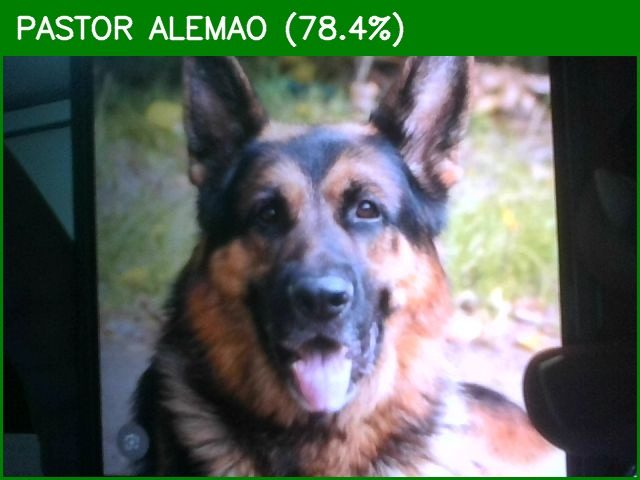

Deteccao registrada em: log_acesso_pet.txt


In [17]:
try:
    # PASSO 1: Captura da foto pela webcam
    print("Ativando camera... Clique em 'Capturar Foto' quando estiver pronto.")
    nome_foto = tirar_foto('foto_capturada.jpg')
    print(f'Foto salva: {nome_foto}')

    # PASSO 2: Classificacao com o modelo treinado
    # verbose=False mantém a saída do console limpa, sem logs do YOLO
    print('\nClassificando a raca...')
    resultado = model(nome_foto, verbose=False)[0]

    # Extraindo a classe com maior probabilidade (top-1)
    id_top1    = resultado.probs.top1
    classe_raw = resultado.names[id_top1]         # nome da classe no dataset
    confianca  = resultado.probs.top1conf.item()  # confianca como float 0.0 a 1.0

    # Convertendo para nome amigavel (ex: German_Shepherd -> Pastor Alemao)
    nome_raca = NOMES_AMIGAVEIS.get(classe_raw, classe_raw)

    # PASSO 3: Resultado no console
    print('\n' + '=' * 50)
    print(f'  RACA DETECTADA: {nome_raca.upper()}')
    print(f'  CONFIANCA:      {confianca * 100:.1f}%')
    print('=' * 50)

    # PASSO 4: Output visual com OpenCV
    img = cv2.imread(nome_foto)
    texto = f'{nome_raca.upper()} ({confianca * 100:.1f}%)'

    # Cor da barra baseada no nivel de confianca do modelo
    #   Verde   >= 70% - alta confianca
    #   Laranja >= 45% - confianca media
    #   Vermelho < 45% - baixa confianca
    if confianca >= 0.70:
        cor = (0, 128, 0)
    elif confianca >= 0.45:
        cor = (0, 165, 255)
    else:
        cor = (0, 0, 180)

    # Barra solida no topo da imagem para destacar o resultado
    cv2.rectangle(img, (0, 0), (img.shape[1], 55), cor, -1)

    # Texto com nome da raca e porcentagem de confianca
    cv2.putText(img, texto, (15, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)

    # Borda colorida ao redor da imagem
    cv2.rectangle(img, (0, 0), (img.shape[1]-1, img.shape[0]-1), cor, 4)

    # Salvando e exibindo o output visual final
    output_path = 'resultado_deteccao.jpg'
    cv2.imwrite(output_path, img)
    print(f'\nOutput visual salvo: {output_path}')
    display(Image(filename=output_path))

    # PASSO 5: Log de deteccao — simulacao IoT
    # Registra cada deteccao com timestamp, simulando um sistema
    # de controle de acesso de pets via camera embarcada
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open('log_acesso_pet.txt', 'a') as log:
        log.write(f'[{timestamp}] Detectado: {nome_raca} | Classe: {classe_raw} | Confianca: {confianca:.2%} | Status: Registrado\n')
    print(f'Deteccao registrada em: log_acesso_pet.txt')

except Exception as err:
    print('\nCamera nao encontrada ou permissao negada no navegador.')
    print(f'Erro detalhado: {err}')


---
## Secao 9 - Validacao com Imagens do Dataset

Testa o modelo com imagens da pasta `valid/` do dataset — **sem precisar usar a camera**.


9 racas encontradas para validacao.

Poodle_26_jpg.rf.a90bf948cf02db959778d41217f1e435.jpg  ->  Poodle  |  99.9%


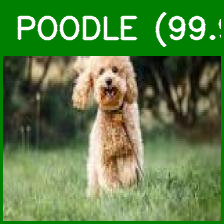

--------------------------------------------------
Dachshund_2_jpg.rf.52497824950afdac212008b53d752b99.jpg  ->  Dachshund  |  77.9%


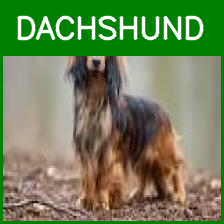

--------------------------------------------------
Beagle_26_jpg.rf.b99a56f3a00d1dcba3f24ddfb8b209e2.jpg  ->  Beagle  |  83.6%


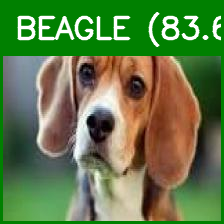

--------------------------------------------------
Bulldog_24_jpg.rf.34447372475372edb778da73852ce732.jpg  ->  Bulldog  |  99.6%


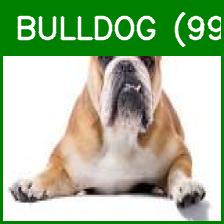

--------------------------------------------------
German-Shepherd_28_jpg.rf.3a1fdafd55b5989e06de503a4b86e04f.jpg  ->  Boxer  |  59.8%


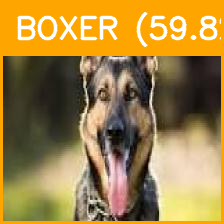

--------------------------------------------------
Rottweiler_14_jpg.rf.1d8b28f601bbd297656d28f9dcafbbbc.jpg  ->  Rottweiler  |  99.7%


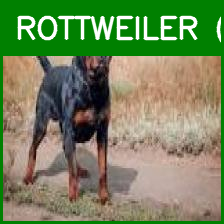

--------------------------------------------------
Boxer_30_jpg.rf.de8cd7be3a12629f620bf0fa89b30f6b.jpg  ->  Boxer  |  99.6%


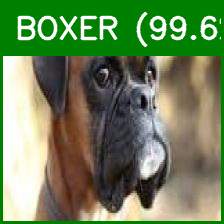

--------------------------------------------------
Golden-Retriever_14_jpg.rf.98321880c20fd1a877bff12eec42964d.jpg  ->  Golden Retriever  |  75.8%


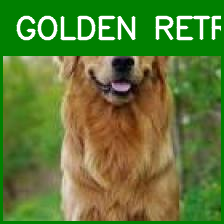

--------------------------------------------------
Labrador-Retriever_20_jpg.rf.4d13a6968377f7c12653ed46228c62d2.jpg  ->  Labrador Retriever  |  94.0%


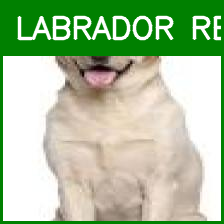

--------------------------------------------------


In [18]:
# Buscando imagens da pasta de validacao do dataset
# O Roboflow organiza automaticamente em subpastas por classe dentro de valid/
imagens_valid = glob.glob(f'{DATASET_PATH}/valid/**/*.jpg', recursive=True)

# Selecionando 1 imagem por raca para uma demonstracao variada
imagens_por_raca = {}
for caminho in imagens_valid:
    raca = os.path.basename(os.path.dirname(caminho))
    if raca not in imagens_por_raca:
        imagens_por_raca[raca] = caminho

imagens_demo = list(imagens_por_raca.values())
print(f'{len(imagens_demo)} racas encontradas para validacao.\n')

for caminho_img in imagens_demo:
    # Carregando a imagem — verificacao antes de processar
    img = cv2.imread(caminho_img)
    if img is None:
        print(f'Imagem nao carregada: {caminho_img}')
        continue

    # Classificando a imagem com o modelo treinado
    res        = model(caminho_img, verbose=False)[0]
    classe_raw = res.names[res.probs.top1]
    confianca  = res.probs.top1conf.item()
    nome_raca  = NOMES_AMIGAVEIS.get(classe_raw, classe_raw)

    # Cor da barra por nivel de confianca
    cor = (0, 128, 0) if confianca >= 0.70 else (0, 165, 255) if confianca >= 0.45 else (0, 0, 180)

    # Output visual: barra + texto sobreposto na imagem
    cv2.rectangle(img, (0, 0), (img.shape[1], 55), cor, -1)
    cv2.putText(img, f'{nome_raca.upper()} ({confianca * 100:.1f}%)',
                (15, 38), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.rectangle(img, (0, 0), (img.shape[1]-1, img.shape[0]-1), cor, 4)

    # Exibindo resultado no console e na tela
    print(f'{os.path.basename(caminho_img)}  ->  {nome_raca}  |  {confianca:.1%}')
    cv2_imshow(img)
    print('-' * 50)


---
## Conclusao

### O que foi implementado neste projeto:

1. **Dataset customizado** — 10 racas anotadas via Roboflow, incluido no repositorio  
2. **Treinamento YOLOv8** — modelo treinado localmente no Colab com as imagens do dataset  
3. **Captura via webcam** — integracao com a camera do navegador no Google Colab  
4. **Output visual com OpenCV** — nome da raca e confianca sobrepostos na imagem   

### Possibilidades de expansao (proximos Sprints):

- **Dashboard em tempo real** — envio dos dados via MQTT para painel web  
- **Mais racas** — expansao do dataset com novas classes  

---

**Referencias:**  
- Ultralytics YOLOv8: https://docs.ultralytics.com/  
- OpenCV: https://opencv.org/



## Observacao Importante para Google Colab

Se estiver executando este notebook no **Google Colab**, habilite a GPU para acelerar o treinamento e a inferencia do modelo YOLOv8.

- Va em: **Ambiente de execucao > Alterar tipo de ambiente de execucao > Acelerador de hardware > GPU (T4)**  
- Isso garante melhor desempenho e menor tempo de treinamento.
